In [2]:
import pandas as pd
import numpy as np
import collections
import networkx as nx
import itertools
from itertools import combinations 
import matplotlib.pyplot as plt
%matplotlib inline
import random


import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend
from ndlib.viz.mpl.TrendComparison import DiffusionTrendComparison

### Loading and Cleaning Wiki Data Discussion Data
Pre-process the raw CSV data for use in building the network. The cleaning process involves filling in missing values, removing excess spaces from text fields, filtering out empty strings, and deleting duplicate rows.

In [3]:
def load_wiki_data(file_path):
    df=pd.read_csv(file_path)
    df=df.dropna()
    columns =['username', 'page_name', 'thread_subject']
    for col in columns:
        df[col]=df[col].astype(str).str.strip()
    
    df=df[(df[columns]!='').all(axis=1)]
    df=df.drop_duplicates()

    return df

First, all unique editors are added to the graph as nodes. Second, the data is grouped according to `thread_subject` and `page_name`, such that each group represents a discussion context. Finally, for each discussion involving at least two different users, the graph connects all pairs of participating editors.
The graph is undirected because the data only shows that two users participated in the same discussion, without indicating who replied to whom. Edge weights are used to account for co-occurrence; if the same pair of editors appears in multiple page-thread discussions, the connection between them becomes stronger.

In [4]:
def generate_network(df):
    graph=nx.Graph()
    user=df['username'].unique()
    graph.add_nodes_from(user)
    group=df.groupby(['thread_subject', 'page_name'])

    for (thread_subject, page_name), group_df in group:
        discussion_user=group_df['username'].unique()

        if len(discussion_user) <2:
            continue
        for user_1, user_2 in combinations(discussion_user, 2):
            if graph.has_edge(user_1, user_2):
                graph[user_1][user_2]['weight']+=1
            else:
                graph.add_edge(user_1, user_2, weight=1)
    return graph

def graph_statistics(graph, network_name):
    degree_sequence=[d for n, d in graph.degree()]
    avg_degree=sum(degree_sequence)/len(degree_sequence)
    weighted_degree_sequence=[d for n, d in graph.degree(weight='weight')]
    avg_weighted_degree=sum(weighted_degree_sequence) / len(weighted_degree_sequence)
    result={
        'Network':network_name,
        'Number of nodes':graph.number_of_nodes(),
        'Number of edges':graph.number_of_edges(),
        'Number of connected components':nx.number_connected_components(graph),
        'Average degree':avg_degree,
        'Average weighted degree':avg_weighted_degree
    }
    return result


In [5]:
small_data='REQUESTS_FOR_COMMENT.csv'
medium_data='PROPERTY_PROPOSAL.csv'
large_data='REQUEST_FOR_DELETION.csv'

df_small_data=load_wiki_data(small_data)
df_medium_data=load_wiki_data(medium_data)
df_large_data=load_wiki_data(large_data)

graph_small=generate_network(df_small_data)
graph_medium=generate_network(df_medium_data)
graph_large=generate_network(df_large_data)

small_result=graph_statistics(graph_small, 'Small Network')
medium_result=graph_statistics(graph_medium, 'Medium Network')
large_result=graph_statistics(graph_large, 'Large Network')

summary_table=pd.DataFrame([small_result, medium_result, large_result])
summary_table['Average degree']=summary_table['Average degree'].round(2)
summary_table['Average weighted degree']=summary_table['Average weighted degree'].round(2)
summary_table

,Network,Number of nodes,Number of edges,Number of connected components,Average degree,Average weighted degree
0,Small Network,888,27569,54,62.09,87.00
1,Medium Network,3058,46154,8,30.19,95.47
2,Large Network,9935,33497,57,6.74,71.36


The `graph_statistics()` function returns summary information for each network, including the number of nodes, the number of edges, the number of connected components, the average degree and the average weighted degree.

As the results show, the three selected datasets exhibit significant differences in terms of scale and structure. The large network comprises the highest number of editors, yet its average degree is significantly lower than that of the small and medium-sized networks, suggesting a wider distribution of participants and fewer connections per editor on average. In contrast, the small network exhibits a higher average degree, indicating that editors are more closely interconnected within this discussion space. The medium-sized network has the fewest connected components, indicating a more unified structure compared to the other two networks.

To provide a clear visual representation of the network structure, I have extracted the largest connected components from the small network. This avoids the need to plot isolated or very small disconnected groups.

Largest connected component of small network:
Number of ndoes: 833
Number of edges: 27567



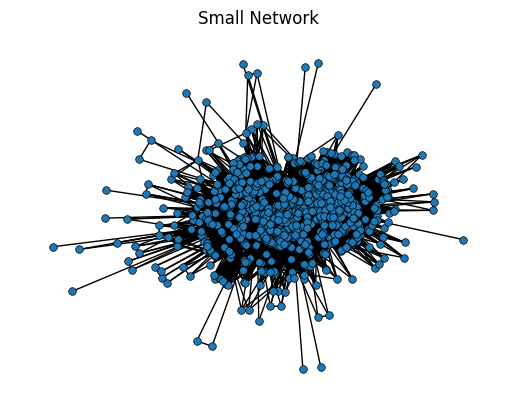

In [6]:
def get_largest_component(graph):
    largest_component=max(nx.connected_components(graph), key=len)
    largest_graph=graph.subgraph(largest_component).copy()
    return largest_graph

def plot_graph(graph, title):
    fig, ax=plt.subplots()
    nx.draw(graph, pos=nx.spring_layout(graph, seed=42), node_size=30, edgecolors='black', linewidths=0.5)
    ax.set_title(title)
    plt.show()

small_largest_component=get_largest_component(graph_small)
print('Largest connected component of small network:')
print('Number of ndoes:', small_largest_component.number_of_nodes())
print('Number of edges:', small_largest_component.number_of_edges())
print()
plot_graph(small_largest_component, 'Small Network')

The visualisation of small network shows that the central region is densely connected, whilst the periphery is populated by edge nodes with weaker connections.

## Task B

Construct the structural characteristics of three Wikidata editor networks and compare them with random graphs of similar degree and density.

Compute a set of standard graph metrics for each real editor network, and then compare them with those of an Erdős–Rényi random graph. 

First, calculate several structural properties of the real graph, including density, average clustering coefficient, the size of the largest connected component, diameter and average path length. Then, calculate the same metrics for the random graph used as a benchmark.

The parameter `seed=22` is used to ensure the reproducibility of the random graph generation. This means that the same pseudo-random graph is generated each time the code is run, making it easier to produce consistent output in reports.

In [7]:
def graph_analyse_compare(graph, seed=22):
    print('Real Graph Analysis')

    print('Density: {}'.format(nx.density(graph)))
    print('Average clustering coefficient: {}'.format(nx.average_clustering(graph)))

    largest_component=max(nx.connected_components(graph), key=len)
    largest_graph=graph.subgraph(largest_component).copy()
    print('Largest connected component size: {}'.format(largest_graph.number_of_nodes()))

    diam=nx.diameter(largest_graph)
    print("Graph diameter: {}".format(diam))

    print("Average path length: {}".format(nx.average_shortest_path_length(largest_graph)))

    print()
    print('='*40)
    print('Random Graph')
    

    n=graph.number_of_nodes()
    e=graph.number_of_edges()
    p=e/(n*(n-1)/2) # The value of `p` is calculated by dividing the observed number of edges by the maximum possible number of undirected edges.

    random_graph=nx.erdos_renyi_graph(n=n, p=p, seed=seed)
    print('Density: {}'.format(nx.density(random_graph)))
    print('Average clustering coefficient: {}'.format(nx.average_clustering(random_graph)))

    random_largest_component=max(nx.connected_components(random_graph), key=len)
    random_largest_graph=random_graph.subgraph(random_largest_component).copy()
    print('Largest connected component size: {}'.format(random_largest_graph.number_of_nodes()))
    random_diam=nx.diameter(random_largest_graph)
    print("Graph diameter: {}".format(random_diam))
    print("Average path length: {}".format(nx.average_shortest_path_length(random_largest_graph)))
    
    return random_graph


To compare the structural characteristics of real-world networks and random networks, I have visualised their degree distributions.

The `degree_distribution_plot()` function plots the degree distribution as a degree-versus-node-count scatter plot. In this plot, the x-axis represents node degree, whilst the y-axis represents the number of nodes with that degree.


In [8]:
def degree_distribution_plot(graph, title):
    degree_sequence=[d for n, d in graph.degree()]
    degree_count = collections.Counter(degree_sequence)
    deg, cnt = zip(*sorted(degree_count.items()))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(deg, cnt)
    plt.title(title)
    plt.ylabel("Count")
    plt.xlabel("Degree")
    plt.show()

def get_graph_summary(graph, network_name, graph_type):
    largest_component=max(nx.connected_components(graph), key=len)
    largest_graph=graph.subgraph(largest_component).copy()
    result={
        'Network':network_name,
        'Graph type':graph_type,
        'Density':nx.density(graph),
        'Avg clustering':nx.average_clustering(graph),
        'Largest connected component size':largest_graph.number_of_nodes(),
        'Diameter':nx.diameter(largest_graph),
        'Avg path length':nx.average_shortest_path_length(largest_graph)
    }
    return result


Small Data
Real Graph Analysis
Density: 0.07000264074672193
Average clustering coefficient: 0.781807757845045
Largest connected component size: 833
Graph diameter: 4
Average path length: 2.0867375796472434

Random Graph
Density: 0.06982997653798105
Average clustering coefficient: 0.06929879071716477
Largest connected component size: 888
Graph diameter: 3
Average path length: 1.942297144946525


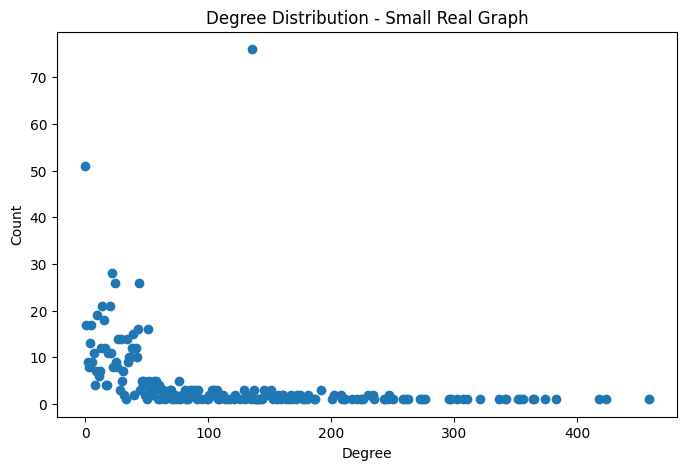

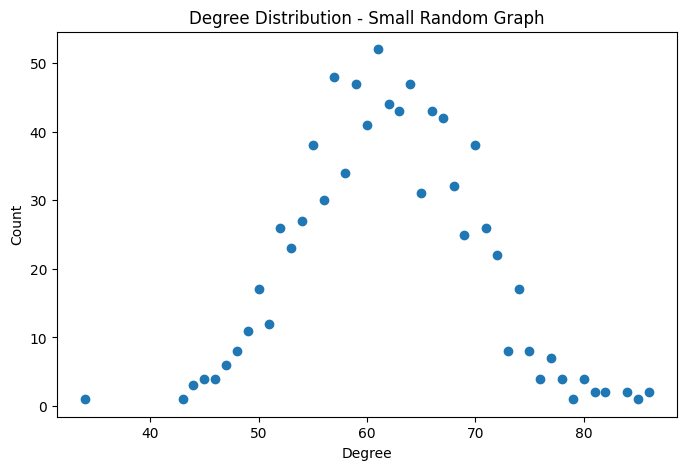


Medium Data
Real Graph Analysis
Density: 0.009874302360235105
Average clustering coefficient: 0.8143765707700285
Largest connected component size: 3051
Graph diameter: 5
Average path length: 2.3841952383255154

Random Graph
Density: 0.009863605235001936
Average clustering coefficient: 0.009802669229928977
Largest connected component size: 3058
Graph diameter: 4
Average path length: 2.726276824913519


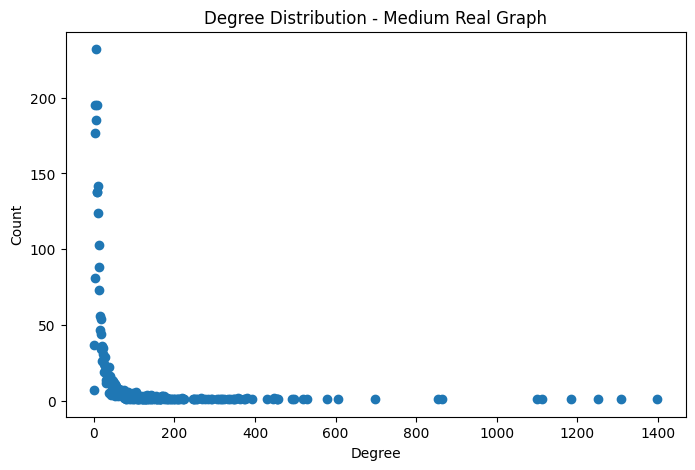

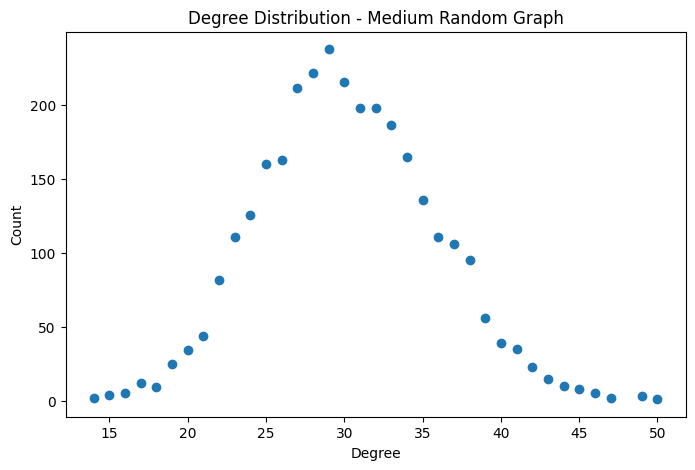


Large Data
Real Graph Analysis
Density: 0.0006788032012794256
Average clustering coefficient: 0.3919515197819165
Largest connected component size: 9870
Graph diameter: 6
Average path length: 2.7019836453282684

Random Graph
Density: 0.0006773441503049467
Average clustering coefficient: 0.0005158242752606108
Largest connected component size: 9925
Graph diameter: 10
Average path length: 5.046858735965123


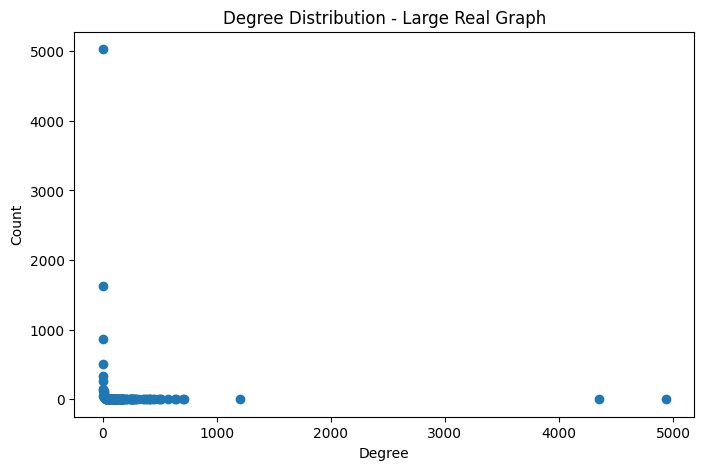

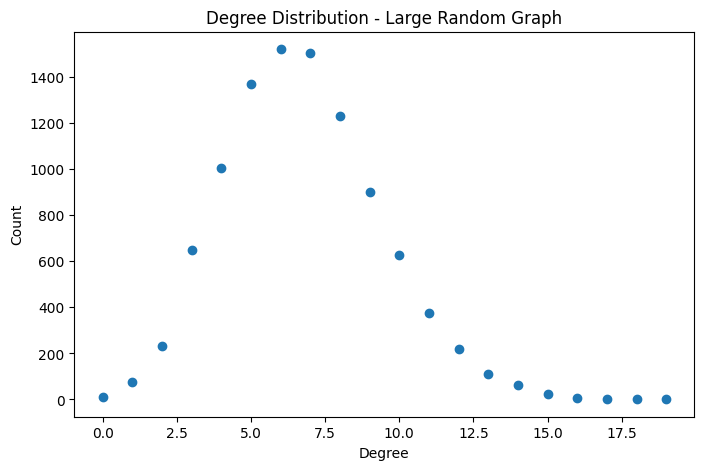

,Network,Graph type,Density,Avg clustering,Largest connected component size,Diameter,Avg path length
0,Small Network,Real,0.0700,0.7818,833,4,2.0867
1,Small Network,Random,0.0698,0.0693,888,3,1.9423
2,Medium Network,Real,0.0099,0.8144,3051,5,2.3842
3,Medium Network,Random,0.0099,0.0098,3058,4,2.7263
4,Large Network,Real,0.0007,0.3920,9870,6,2.7020
5,Large Network,Random,0.0007,0.0005,9925,10,5.0469


In [9]:
all_results=[]
print('Small Data')
random_small=graph_analyse_compare(graph_small)
small_real_result=get_graph_summary(graph_small, 'Small Network', 'Real')
small_random_result=get_graph_summary(random_small, 'Small Network', 'Random')
all_results.append(small_real_result)
all_results.append(small_random_result)
degree_distribution_plot(graph_small, 'Degree Distribution - Small Real Graph')
degree_distribution_plot(random_small, 'Degree Distribution - Small Random Graph')

print()

print('Medium Data')
random_medium=graph_analyse_compare(graph_medium)
medium_real_result=get_graph_summary(graph_medium, 'Medium Network', 'Real')
medium_random_result=get_graph_summary(random_medium, 'Medium Network', 'Random')
all_results.append(medium_real_result)
all_results.append(medium_random_result)
degree_distribution_plot(graph_medium, 'Degree Distribution - Medium Real Graph')
degree_distribution_plot(random_medium, 'Degree Distribution - Medium Random Graph')

print()

print('Large Data')
random_large=graph_analyse_compare(graph_large)
large_real_result=get_graph_summary(graph_large, 'Large Network', 'Real')
large_random_result=get_graph_summary(random_large, 'Large Network', 'Random')
all_results.append(large_real_result)
all_results.append(large_random_result)
degree_distribution_plot(graph_large, 'Degree Distribution - Large Real Graph')
degree_distribution_plot(random_large, 'Degree Distribution - Large Random Graph')

comparison_table=pd.DataFrame(all_results)
comparison_table['Density']=comparison_table['Density'].round(4)
comparison_table['Avg clustering']=comparison_table['Avg clustering'].round(4)
comparison_table['Avg path length']=comparison_table['Avg path length'].round(4)
comparison_table

Random graphs exhibit a relatively dense and concentrated degree distribution, with the majority of nodes having a degree close to the average. In contrast, the real network of editors exhibits a long-tailed and highly skewed degree distribution, indicating that whilst many editors have relatively few interactions, a small number of editors have high degrees.

The comparison table shows that, the clustering coefficient of the real-world graph is significantly higher than that of the corresponding random graph in all three cases, suggesting that interactions among Wikidata editors are not randomly distributed, but rather form strong local clusters of co-participation. Furthermore, the average path length and diameter of the real-world graph remain relatively small, suggesting that despite strong local clustering, these networks remain compact on a global scale, with most nodes connected via only a few steps. 

### Task C

As the data only recorded instances where editors appeared together in the same page discussion thread, without recording the direction or timing of replies, it is difficult to identify trolls directly from the raw data. Therefore, I considered Task C to be a context-based analysis, and assume that editors of structural significance constitute the initial cases of malicious provocation.

The function `one_trolling(graph)` selects the editor with the highest weighted degree. This identifies the editor who appears most frequently within a co-discussion context. 
The function `two_trolling(graph)` selects the pairs of editors connected by the edges with the highest weights. This identifies pairs of editors who repeatedly appear together in discussions.

In [10]:
def one_trolling(graph):
    weighted_degree_list=list(graph.degree(weight='weight'))
    weighted_degree_list=sorted(weighted_degree_list, key=lambda x:x[1], reverse=True)
    trolling=weighted_degree_list[0][0]
    print('Assumed initial trolling editor:')
    print('Editor:', trolling)
    print('Weighted degree:', weighted_degree_list[0][1])
    print()
    return [trolling]

def two_trolling(graph):
    edge_list=list(graph.edges(data=True))
    edge_list=sorted(edge_list, key=lambda x:x[2].get('weight', 1), reverse=True)
    editor_1=edge_list[0][0]
    editor_2=edge_list[0][1]
    edge_weight=edge_list[0][2].get('weight', 1)
    print('Assumed initial trolling editor pair:')
    print('Editor 1:', editor_1)
    print('Editor 2:', editor_2)
    print('edge weight:', edge_weight)
    print()

    return [editor_1, editor_2]

The function `build_threshold_model()` implements a threshold diffusion process using NDlib. In this model, a node is infected only when 50% of its neighbours are already infected. In this analysis, I set `threshold=0.5`, which means that a node will adopt the behaviour only when at least half of its neighbouring nodes are already infected.

`final_infected_nodes()` extracts all nodes that were infected at some point during the simulation. Subsequently, `assess_spread()` useed this output to calculate `spread_ratio`, which is defined as the proportion of neighbours of the assumed ‘trolls’ who have been infected.

Furthermore, when there are two presumed troll editors, the shortest paths between them and among their shared neighbours were calculated to determine whether the pair of editors are closely clustered within the same local neighbourhood.

In [11]:
def build_threshold_model(graph, fraction, node_thresholds, init_spreaders=None):
    model = ep.ThresholdModel(graph)
    config = mc.Configuration()
    if init_spreaders is None:
        config.add_model_parameter("fraction_infected", fraction)
    else: 
        config.add_model_initial_configuration("Infected", init_spreaders)

    for i, node in enumerate(graph.nodes()):
        config.add_node_configuration("threshold", node, node_thresholds[i])
    model.set_initial_status(config)
    iterations = model.iteration_bunch(50)
    trends = model.build_trends(iterations)

    return model, config, iterations, trends


def final_infected_nodes(iterations):
    infected_nodes=set()
    for iteration in iterations:
        iteration_status_dict=iteration['status']
        for node, status in iteration_status_dict.items():
            if status==1:
                infected_nodes.add(node)
    return infected_nodes


def assess_spread(graph, trolling, threshold=0.5, lower_threshold=0.15, high_threshold=0.30): 
    # A spread ratio below 0.15 indicates limited evidence of spread, whilst a spread ratio above 0.30 provides stronger evidence that the behaviour may have spread to neighbouring editors.
    node_thresholds=[threshold]*graph.number_of_nodes()
    model, config, iterations, trends=build_threshold_model(
        graph, fraction=None, node_thresholds=node_thresholds, init_spreaders=trolling
    )
    infected_nodes=set()
    for iteration in iterations:
        iteration_status_dict=iteration['status']
        for node, status in iteration_status_dict.items():
            if status==1:
                infected_nodes.add(node)
    neighbors=set()
    for troll in trolling:
        neighbors.update(graph.neighbors(troll))

    infected_neighbors=neighbors.intersection(infected_nodes)
    if len(neighbors)==0:
        spread_ratio=0
    else:
        spread_ratio=len(infected_neighbors)/len(neighbors)

    shortest_path=None
    common_neighbors=set()
    if len(trolling)==2:
        if nx.has_path(graph, trolling[0], trolling[1]):
            shortest_path=nx.shortest_path(graph, trolling[0], trolling[1])
            common_neighbors=set(graph.neighbors(trolling[0])).intersection(set(graph.neighbors(trolling[1])))
    
    if spread_ratio>high_threshold:
        summary='It is highly likely that this behaviour has spread to neighbouring editors.'
    elif spread_ratio<lower_threshold:
        summary='It is highly likely that this behaviour has not yet spread to other editors.'
    else:
        summary='Based on the available evidence, it is not yet clear whether this behaviour has spread to neighbouring editors.'
    
    print('Spread ratio:', spread_ratio)
    print('Summary:', summary)

    return {'model': model, 'trends':trends, 'infected_nodes':infected_nodes, 'spread_ratio':spread_ratio, 'shortest_path': shortest_path, 'common_neighbors': common_neighbors, 'summary':summary}

`one_or_two_trolling()` first evaluated the single-editor case. Secondly, when there were a pair of editors, it evaluates the dual-editor case, using two assumed troll editors as the initial spreaders.

In [12]:
def build_priority_list(graph, trolling, spread_result, top_n=5):
    infected_nodes=spread_result['infected_nodes']
    priority_list=[]

    trolling_neighbors=set()
    for troll in trolling:
        trolling_neighbors.update(graph.neighbors(troll))
    
    for node in trolling_neighbors:
        if node in trolling:
            continue
        infected_editor=1 if node in infected_nodes else 0
        total_weight_trolling=0
        total_common_neighbors=0

        for troll in trolling:
            if graph.has_edge(troll, node):
                total_weight_trolling=total_weight_trolling+graph[troll][node].get('weight', 1)
            
            trolling_neighbors=set(graph.neighbors(troll))
            neighbors_node=set(graph.neighbors(node))
            total_common_neighbors=total_common_neighbors+len(trolling_neighbors.intersection(neighbors_node))
        
        priority_list.append({
            'editor':node,
            'infected_editor':infected_editor,
            'weight_score':total_weight_trolling,
            'common_neighbor_score': total_common_neighbors
        })
    priority_df=pd.DataFrame(priority_list)
    if len(priority_df)==0:
        return priority_df
    
    priority_df=priority_df.sort_values(by=['infected_editor', 'weight_score', 'common_neighbor_score'], ascending=False).head(top_n).reset_index(drop=True)
    return priority_df

def plot_trolling_comparison(spread_result_one, spread_result_two):
    viz=DiffusionTrendComparison([spread_result_one['model'], spread_result_two['model']],
                                 [spread_result_one['trends'], spread_result_two['trends']], statuses=['Infected'])
    viz.plot()

def one_or_two_trolling(graph, trolling,threshold=0.5, top_n=5):
    if len(trolling)==0:
        print('No trolling editors were found')
        print()
        return None, None, None, None
    print('If there is only one assumed trolling editor')
    print()

    spread_result_one=assess_spread(graph=graph, trolling=[trolling[0]], threshold=threshold)
    priority_one=build_priority_list(graph=graph, trolling=[trolling[0]], spread_result=spread_result_one, top_n=top_n)
    
    print(priority_one)
    print()

    priority_two=None
    spread_result_two=None

    if len(trolling)==2:
        print('If there are two assumed trolling editors')
        print()

        spread_result_two=assess_spread(graph=graph, trolling=trolling, threshold=threshold)
        priority_two=build_priority_list(graph=graph, trolling=trolling, spread_result=spread_result_two, top_n=top_n)
        print(priority_two)
        print()

        plot_trolling_comparison(spread_result_one, spread_result_two)
    
    else:
        print('Only one assumed trolling editor was detected during this operation; therefore, the two edits in question were not analysed')
        print()

    return priority_one, priority_two, spread_result_one, spread_result_two
    
def plot_network_comparison(outcome_small, outcome_medium, outcome_large):
    viz=DiffusionTrendComparison(
        [outcome_small['model'],
         outcome_medium['model'],
         outcome_large['model']],
         [outcome_small['trends'],
         outcome_medium['trends'],
         outcome_large['trends']],
         statuses=['Infected']
    )
    viz.plot()



In [13]:
def run_all_function(graph, graph_name, threshold=0.5, top_n=5):
    print('Task C:', graph_name)
    print()

    largest_graph=get_largest_component(graph)
    print('The largest connected component:')
    print('Number of nodes:', largest_graph.number_of_nodes())
    print('Number of edges:', largest_graph.number_of_edges())
    print()

    print('1. Select assumed trolling editor')
    one_troll=one_trolling(largest_graph)
    two_troll=two_trolling(largest_graph)

    print('2. Spread assessment and priority list')
    print()

    print('One editor case')
    priority_one_single, priority_two_single, spread_outcome_one_single, spread_outcome_two_single=one_or_two_trolling(
        graph=largest_graph,
        trolling=one_troll,
        threshold=threshold,
        top_n=top_n
    )

    print('Two editor case')
    priority_one_pair, priority_two_pair, spread_outcome_one_pair, spread_outcome_two_pair=one_or_two_trolling(
        graph=largest_graph,
        trolling=two_troll,
        threshold=threshold,
        top_n=top_n
    )
    return {
        'graph_name':graph_name,
        'one_troll':one_troll,
        'two_troll':two_troll,
        'priority_one_single':priority_one_single,
        'priority_two_single':priority_two_single,
        'spread_outcome_one_single':spread_outcome_one_single,
        'spread_outcome_two_single':spread_outcome_two_single,
        'priority_one_pair':priority_one_pair,
        'priority_two_pair':priority_two_pair,
        'spread_outcome_one_pair':spread_outcome_one_pair,
        'spread_outcome_two_pair':spread_outcome_two_pair,
    }

Task C: Small network

The largest connected component:
Number of nodes: 833
Number of edges: 27567

1. Select assumed trolling editor
Assumed initial trolling editor:
Editor: Rschen7754
Weighted degree: 1222

Assumed initial trolling editor pair:
Editor 1: Jasper Deng
Editor 2: Rschen7754
edge weight: 34

2. Spread assessment and priority list

One editor case
If there is only one assumed trolling editor

Spread ratio: 0.0
Summary: It is highly likely that this behaviour has not yet spread to other editors.
         editor  infected_editor  weight_score  common_neighbor_score
0   Jasper Deng                0            34                    302
1     Ajraddatz                0            30                    238
2        Vogone                0            28                    234
3         Stryn                0            19                    322
4  ArthurPSmith                0            18                    277

Only one assumed trolling editor was detected during this operati

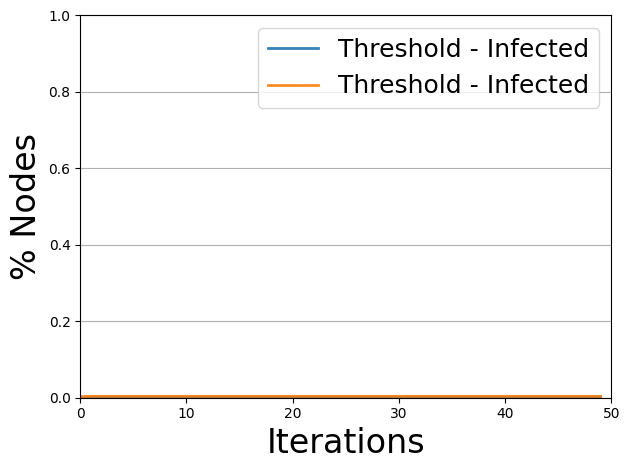

Task C: Medium network

The largest connected component:
Number of nodes: 3051
Number of edges: 46154

1. Select assumed trolling editor
Assumed initial trolling editor:
Editor: ديفيد عادل وهبة خليل 2
Weighted degree: 15088

Assumed initial trolling editor pair:
Editor 1: ديفيد عادل وهبة خليل 2
Editor 2: Pintoch
edge weight: 1992

2. Spread assessment and priority list

One editor case
If there is only one assumed trolling editor

Spread ratio: 0.01145912910618793
Summary: It is highly likely that this behaviour has not yet spread to other editors.
                                   editor  infected_editor  weight_score  \
0                                HedgeHog                1             4   
1                                Malvoört                1             4   
2                           Labattblueboy                1             1   
3             Julian Jarosch (digicademy)                1             1   
4  2001:7D0:81F7:B580:DDFA:F670:B74B:12B4                1       

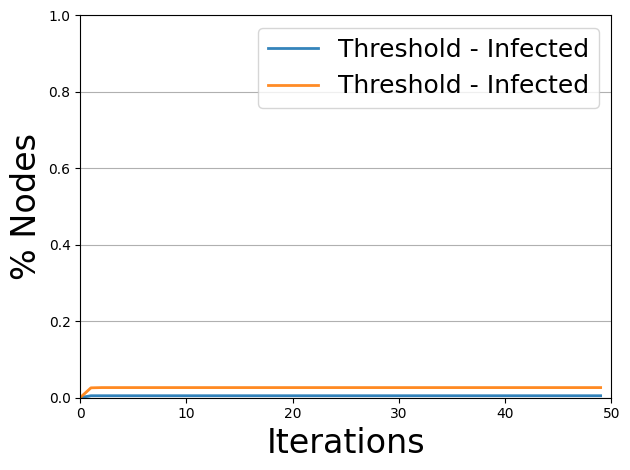

Task C: Large network

The largest connected component:
Number of nodes: 9870
Number of edges: 33488

1. Select assumed trolling editor
Assumed initial trolling editor:
Editor: BeneBot*
Weighted degree: 242208

Assumed initial trolling editor pair:
Editor 1: Succu
Editor 2: BeneBot*
edge weight: 14325

2. Spread assessment and priority list

One editor case
If there is only one assumed trolling editor

Spread ratio: 0.6192881745120551
Summary: It is highly likely that this behaviour has spread to neighbouring editors.
           editor  infected_editor  weight_score  common_neighbor_score
0      Bluemersen                1           580                      5
1           JWbot                1           561                      1
2  Kennyannydenny                1           450                      1
3          Bthfan                1           367                      2
4          Llecco                1           334                      1

Only one assumed trolling editor was detect

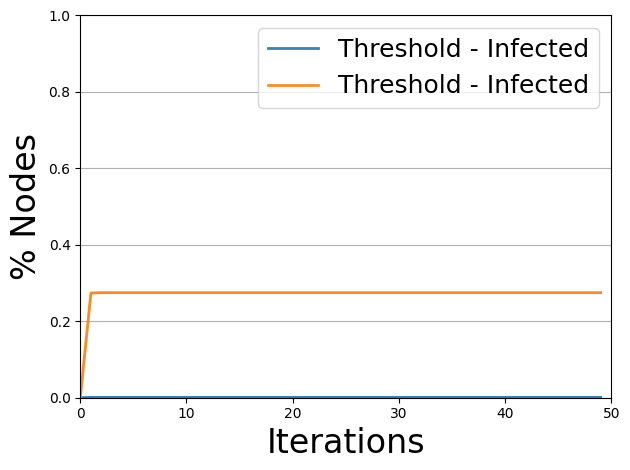

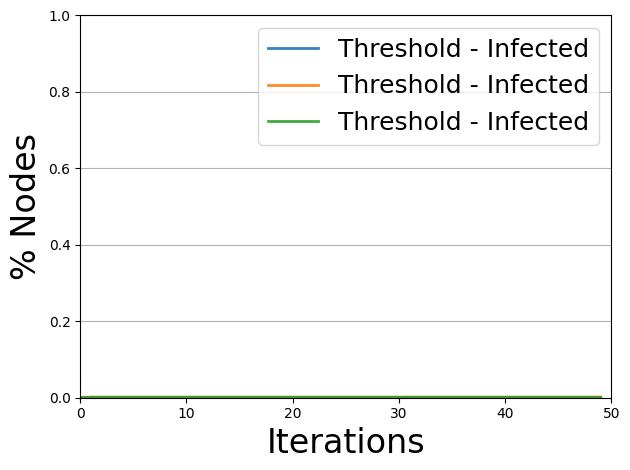

In [14]:
results_small=run_all_function(graph_small, 'Small network', threshold=0.5, top_n=5)
results_medium=run_all_function(graph_medium, 'Medium network', threshold=0.5, top_n=5)
results_large=run_all_function(graph_large, 'Large network', threshold=0.5, top_n=5)
print()

if (
    results_small['spread_outcome_one_pair'] is not None and
    results_medium['spread_outcome_one_pair'] is not None and
    results_large['spread_outcome_one_pair'] is not None
):
    plot_network_comparison(
        results_small['spread_outcome_one_pair'],
        results_medium['spread_outcome_one_pair'],
        results_large['spread_outcome_one_pair']
    )
else:
    print('Unable to generate a network comparison diagram')

Across the three networks, the results of the threshold model indicate that information diffusion depends not only on network size, but also on the assumed structural position and number of trolling editors. Under the selected majority threshold setting (50% threshold), the reach of information in small and medium-sized networks is very limited in both single-editor and two-editor cases. This indicated that under relatively strict threshold assumptions, local connectivity alone is insufficient to trigger wider-scale spread.

In contrast, large networks exhibited a more distinct pattern of variation. In the one-editor case, the scope of spread remained limited; however, in the two-editor case, the spread ratio increased significantly, indicating that jointly positioned initial spreaders can generate a stronger spreading effect. Consequently, large networks are more sensitive to the number of initial ‘troll’ editors and their structural positions.

As shown in the graph, the spread curves for small and medium-sized networks remain close to zero, which is consistent with lower spread ratios. In contrast, in the two-editor case, the curves for large networks exhibited a more significant upward trend

In [15]:
def build_summary_table(results_small, results_medium, results_large):
    task_c_summary_table=pd.DataFrame([{
        'Network':'Small network',
        'One editor spread ratio':results_small['spread_outcome_one_single']['spread_ratio'],
        'Two editor spread ratio':results_small['spread_outcome_two_pair']['spread_ratio']
    },
    {
        'Network':'Medium network',
        'One editor spread ratio':results_medium['spread_outcome_one_single']['spread_ratio'],
        'Two editor spread ratio':results_medium['spread_outcome_two_pair']['spread_ratio']
    },
    {
        'Network':'Large network',
        'One editor spread ratio':results_large['spread_outcome_one_single']['spread_ratio'],
        'Two editor spread ratio':results_large['spread_outcome_two_pair']['spread_ratio']
    }
    ])
    task_c_summary_table['One editor spread ratio']=task_c_summary_table['One editor spread ratio'].round(4)
    task_c_summary_table['Two editor spread ratio']=task_c_summary_table['Two editor spread ratio'].round(4)
    return task_c_summary_table

task_c_summary_table=build_summary_table(results_small, results_medium, results_large)
task_c_summary_table

,Network,One editor spread ratio,Two editor spread ratio
0,Small network,0.0000,0.0058
1,Medium network,0.0115,0.0561
2,Large network,0.6193,0.6173
